# Preprocesamiento para Machine Learning

En este notebook se prepara el dataset para el entrenamiento de modelos de clasificación.

## Objetivos

- Montar Google Drive
- Cargar el dataset tratado
- Eliminar columnas no predictivas si aún existen
- Identificar variables categóricas y numéricas
- Aplicar encoding a las variables categóricas
- Separar variables predictoras y variable objetivo
- Dejar el dataset listo para el modelado

##Montar en Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Importar librerías necesarias

In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

##Definir la ruta del proyecto

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/TelecomX_Churn_ML"

DATA_PROCESSED_PATH = os.path.join(PROJECT_PATH, "data", "processed")
NOTEBOOKS_PATH = os.path.join(PROJECT_PATH, "notebooks")

DATASET_PATH = os.path.join(DATA_PROCESSED_PATH, "TelecomX_clean.csv")

print("Ruta del proyecto:", PROJECT_PATH)
print("Ruta del dataset:", DATASET_PATH)
print("Ruta notebooks:", NOTEBOOKS_PATH)

Ruta del proyecto: /content/drive/MyDrive/TelecomX_Churn_ML
Ruta del dataset: /content/drive/MyDrive/TelecomX_Churn_ML/data/processed/TelecomX_clean.csv
Ruta notebooks: /content/drive/MyDrive/TelecomX_Churn_ML/notebooks


##Cargar el dataset

In [4]:
df = pd.read_csv(DATASET_PATH)

df.head()

,id_cliente,abandono,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,servicio_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cargo_diario
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


##Eliminamos la columna id_cliente ya que no aporta valor al modelo

In [5]:
df = df.drop(columns=["id_cliente"])

df.head()

,abandono,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,servicio_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cargo_diario
0,0,Female,0,1,1,9,1,0,DSL,No,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1,DSL,No,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,No,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,No,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,No,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


##Confirmar variable objetivo y variables predictoras

In [6]:
target = "abandono"

print("Variable objetivo:", target)
print("Valores únicos del target:", df[target].unique())

Variable objetivo: abandono
Valores únicos del target: [0 1]


##Identificar variables categóricas y numéricas

In [7]:
columnas_categoricas = df.select_dtypes(include=["object"]).columns.tolist()
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

if target in columnas_numericas:
    columnas_numericas.remove(target)


print("Variables categóricas:")
print(columnas_categoricas)

print("\nVariables numéricas:")
print(columnas_numericas)

Variables categóricas:
['genero', 'servicio_internet', 'seguridad_online', 'respaldo_online', 'tipo_contrato', 'metodo_pago']

Variables numéricas:
['adulto_mayor', 'tiene_pareja', 'tiene_dependientes', 'antiguedad_meses', 'servicio_telefono', 'lineas_multiples', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'factura_digital', 'cargo_mensual', 'cargo_total', 'cargo_diario']


##Aplicar encoding a variables categóricas

In [8]:
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

df_encoded.head()

,abandono,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,proteccion_dispositivo,soporte_tecnico,streaming_tv,...,servicio_internet_No,seguridad_online_No internet service,seguridad_online_Yes,respaldo_online_No internet service,respaldo_online_Yes,tipo_contrato_One year,tipo_contrato_Two year,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
0,0,0,1,1,9,1,0,0,1,1,...,False,False,False,False,True,True,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,1,0,0,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,0,1,0,1,...,False,False,False,False,True,False,False,False,True,False
4,1,1,1,0,3,1,0,0,1,1,...,False,False,False,False,False,False,False,False,False,True


##Verificar resultado del encoding

In [9]:
print("Dimensiones después del encoding:", df_encoded.shape)
print("\nTipos de datos:")
print(df_encoded.dtypes.value_counts())

Dimensiones después del encoding: (7032, 27)

Tipos de datos:
int64      12
bool       12
float64     3
Name: count, dtype: int64


##Confirmar que no queden variables de texto

In [10]:
remaining_object_cols = df_encoded.select_dtypes(include=["object"]).columns.tolist()

print("Columnas tipo object restantes:", remaining_object_cols)

Columnas tipo object restantes: []


## Verificación de la proporción de cancelación (Churn)

En esta sección se analiza la proporción de clientes que cancelaron el servicio frente a aquellos que permanecen activos.

Este análisis es importante porque un desbalance significativo entre clases puede afectar el desempeño de los modelos predictivos.

##Conteo variable objetivo

In [11]:
df_encoded["abandono"].value_counts()

,count
abandono,
0,5163
1,1869


##Proporción de Churn

In [12]:
df_encoded["abandono"].value_counts(normalize=True) * 100

,proportion
abandono,
0,73.421502
1,26.578498


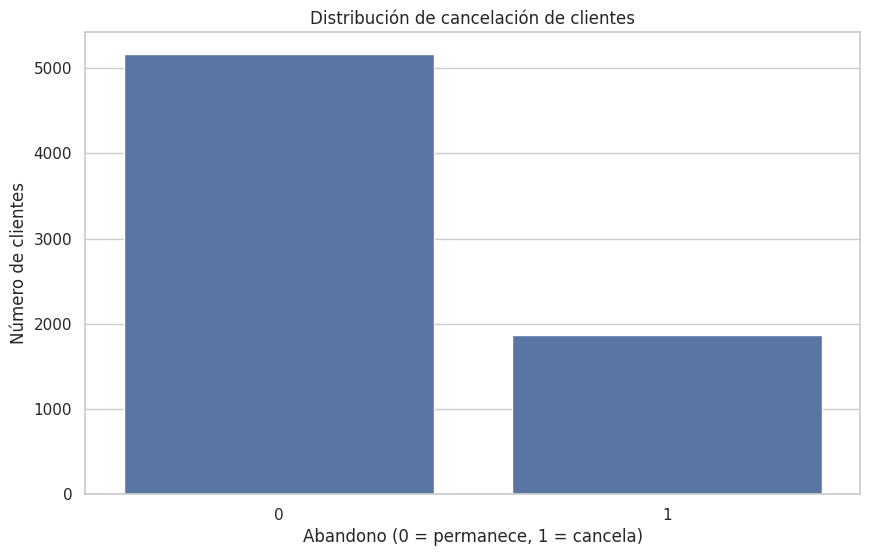

In [13]:
sns.countplot(x="abandono", data=df_encoded)

plt.title("Distribución de cancelación de clientes")
plt.xlabel("Abandono (0 = permanece, 1 = cancela)")
plt.ylabel("Número de clientes")

plt.show()

## Interpretación

La variable `abandono` muestra que aproximadamente el **26.6% de los clientes cancelaron el servicio**, mientras que el **73.4% permanecen activos**.

Esto indica la presencia de un **desbalance moderado entre las clases**, lo cual es común en problemas de churn. Durante la etapa de modelado será importante considerar métricas adicionales como **precision, recall y F1-score**, además de accuracy, para evaluar correctamente el desempeño de los modelos.

## Evaluación de la necesidad de normalización o estandarización

Antes de aplicar técnicas de escalado a los datos, se realizará un análisis de las **variables numéricas** del dataset. Este paso es importante porque algunos algoritmos de *Machine Learning* son sensibles a la escala de los datos.

Modelos basados en distancia o gradiente, como **K-Nearest Neighbors (KNN), Support Vector Machines (SVM), Regresión Logística y Redes Neuronales**, pueden verse afectados cuando las variables tienen escalas muy diferentes. En estos casos, técnicas como **normalización** o **estandarización** ayudan a mejorar el desempeño del modelo.

Por otro lado, algoritmos basados en árboles de decisión, como **Decision Tree, Random Forest o XGBoost**, no dependen de la escala de las variables, por lo que no requieren necesariamente este tipo de preprocesamiento.

En esta sección se analizarán las variables numéricas del dataset para identificar sus rangos y distribuciones, y así determinar si es necesario aplicar **normalización o estandarización** antes de entrenar los modelos predictivos.

In [14]:
print("Variables numéricas:")
print(columnas_numericas)

Variables numéricas:
['adulto_mayor', 'tiene_pareja', 'tiene_dependientes', 'antiguedad_meses', 'servicio_telefono', 'lineas_multiples', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'factura_digital', 'cargo_mensual', 'cargo_total', 'cargo_diario']


In [15]:
df_encoded[columnas_numericas].describe()

,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,factura_digital,cargo_mensual,cargo_total,cargo_diario
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,2.159940
std,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.345000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Análisis de las variables numéricas

A partir de las estadísticas descriptivas se observan dos tipos de variables numéricas en el dataset:

1. **Variables binarias (0/1)** como `adulto_mayor`, `tiene_pareja`, `tiene_dependientes`, entre otras. Estas variables ya se encuentran en la misma escala y no requieren normalización.

2. **Variables numéricas continuas**, como `antiguedad_meses`, `cargo_mensual`, `cargo_total` y `cargo_diario`, que presentan escalas diferentes. En particular, `cargo_total` tiene valores considerablemente mayores que el resto de las variables.

Debido a estas diferencias de escala, algunos modelos de Machine Learning sensibles a la escala de los datos podrían verse afectados. Por esta razón se evaluará aplicar **estandarización** en las variables numéricas continuas.

##Guardamos el dataset para uso posterior

In [16]:
output_path = "/content/drive/MyDrive/TelecomX_Churn_ML/data/processed/TelecomX_encoded.csv"

df_encoded.to_csv(output_path, index=False)

print("Dataset guardado correctamente en:")
print(output_path)

Dataset guardado correctamente en:
/content/drive/MyDrive/TelecomX_Churn_ML/data/processed/TelecomX_encoded.csv
